# **Lab 4: Edges and Features**
# Name: Qiaoxuan Zhang
# Student \#: 3814986

In [1]:
import numpy as np
from scipy import signal
from scipy import ndimage as ndi
import skimage.io
from skimage.filters import gaussian, sobel, prewitt, roberts, scharr
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.feature import CENSURE, ORB, SIFT
from skimage.feature import corner_harris, corner_shi_tomasi
from skimage.feature import corner_subpix, corner_peaks
from skimage.transform import warp, AffineTransform
from skimage.color import rgb2gray
from skimage import data
import matplotlib.pyplot as plt
import cv2

## 1. Convolution

Use Python functions `scipy.signal.convolve2d` or `scipy.signal.convolve`. Here are the links to the function documentation.
https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html
https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html

### 1. a.  Convolve the 2D image $I$ with the 2D kernel $G$, both given below. To properly handle the borders, <u>extend the input by replicating the values, and set the output size to be the same as the input</u>.

$$I = \begin{bmatrix} 5&4&0&3 \\ 6&2&1&8 \\ 7&9&4&2 \\ 8&3&6&1\end{bmatrix} \qquad G = \frac{1}{16}\begin{bmatrix} 1&2&1 \\ 2&4&2 \\ 1&2&1\end{bmatrix} \qquad $$

In [2]:
im = np.array([[5, 4, 0, 3],
               [6, 2, 1, 8],
               [7, 9, 4, 2],
               [8, 3, 6, 1]])
conv = np.array([[1, 2, 1],
                 [2, 4, 2],
                 [1, 2, 1]]) / 16

im_conv = signal.convolve2d(im, conv, "same")
print(im_conv)

[[2.625  2.3125 1.625  1.8125]
 [4.0625 4.     3.125  3.    ]
 [4.9375 5.5625 4.125  2.5625]
 [3.8125 4.3125 3.1875 1.5   ]]


### 1. b. Repeat the computation of the same problem using the separable version of the kernel. First convolve with the horizontal $\displaystyle\frac{1}{4}\begin{bmatrix} 1&2&1 \end{bmatrix}$, then with the vertical $\displaystyle\frac{1}{4}\begin{bmatrix} 1\\2\\1 \end{bmatrix}$. Change the order by convolving the vertical first then the horizontal. Are the results the same? Why?

In [3]:
conv_h = np.array([[1, 2, 1]]) / 4
conv_v = conv_h.T

# convolve with horizontal first, then vertical
im_conv_h = signal.convolve2d(im, conv_h, "same")
im_conv_h_conv_v = signal.convolve2d(im_conv_h, conv_v, "same")

print("Convolve with horizontal first, then vertical:")
print(im_conv_h_conv_v)

im_conv_v = signal.convolve2d(im, conv_v, "same")
im_conv_v_conv_h = signal.convolve2d(im_conv_v, conv_h, "same")

print("\nConvolve with vertical first, then horizontal:")
print(im_conv_v_conv_h)


Convolve with horizontal first, then vertical:
[[2.625  2.3125 1.625  1.8125]
 [4.0625 4.     3.125  3.    ]
 [4.9375 5.5625 4.125  2.5625]
 [3.8125 4.3125 3.1875 1.5   ]]

Convolve with vertical first, then horizontal:
[[2.625  2.3125 1.625  1.8125]
 [4.0625 4.     3.125  3.    ]
 [4.9375 5.5625 4.125  2.5625]
 [3.8125 4.3125 3.1875 1.5   ]]


The two results are the same, because both the horizontal and vertical convolutions are gaussian kernals of variance $\sigma^2=0.5$, and they are decomposition of the 2D Gaussian convolution $G = gauss_{0.5}(x,y)$. Therefore, they are separable:
\begin{align*}
I \circledast G &= \left(I \circledast \frac{1}{4}\begin{bmatrix} 1&2&1 \end{bmatrix}\right) \circledast \frac{1}{4}\begin{bmatrix} 1\\2\\1 \end{bmatrix} \\
&= \left(I \circledast \frac{1}{4}\begin{bmatrix} 1\\2\\1 \end{bmatrix}\right) \circledast \frac{1}{4}\begin{bmatrix} 1&2&1 \end{bmatrix}
\end{align*}
That is,
$$\left(I \circledast G_h\right) \circledast G_v = \left(I \circledast G_v\right) \circledast G_h$$

### 1. c. Compare results from (a) and (b). Are they the same? Why?

The results from (a) and (b) are the same. As described above, not only do the horizontal and vertical convolutions in (b) separable, they combine into the 2D Gaussian kernal $G$ in (a). Since convolution is associative, we have
$$\left(I \circledast G_h\right) \circledast G_v = I \circledast \left(G_h \circledast G_v\right) = I \circledast G$$
We can also swap $G_h$ and $G_v$ in the above equation and obtain the same result:
$$\left(I \circledast G_v\right) \circledast G_h = I \circledast \left(G_v \circledast G_h\right) = I \circledast G$$
Therefore, the results from (a) and (b) are the same.

## 2. The first derivative. Compute the gradient of an image in Python according to the following pseudocode. Use `scipy.ndimage.sobel()` to get $G_x(x,y)$ and $G_y(x,y)$. Or define your own derivative operator such as \begin{align*} Sobel_x &= gauss_{0.5}(y) \circledast \dot gauss_{0.5}(x) = \frac{1}{4}\begin{bmatrix} 1\\2\\1 \end{bmatrix} \circledast \frac{1}{2}\begin{bmatrix} 1&0&-1 \end{bmatrix} = \frac{1}{8}\begin{bmatrix} 1&0&-1\\2&0&-2\\1&0&-1 \end{bmatrix} \\ Sobel_y &= gauss_{0.5}(x) \circledast \dot gauss_{0.5}(y) = \frac{1}{4}\begin{bmatrix} 1&2&1 \end{bmatrix} \circledast \frac{1}{2}\begin{bmatrix} 1\\0\\-1 \end{bmatrix} = \frac{1}{8}\begin{bmatrix} 1&2&1\\0&0&0\\-1&-2&-1 \end{bmatrix} \end{align*} And calculate $G_x(x,y)$ and $G_y(x,y)$ by `scipy.signal.convolve`.

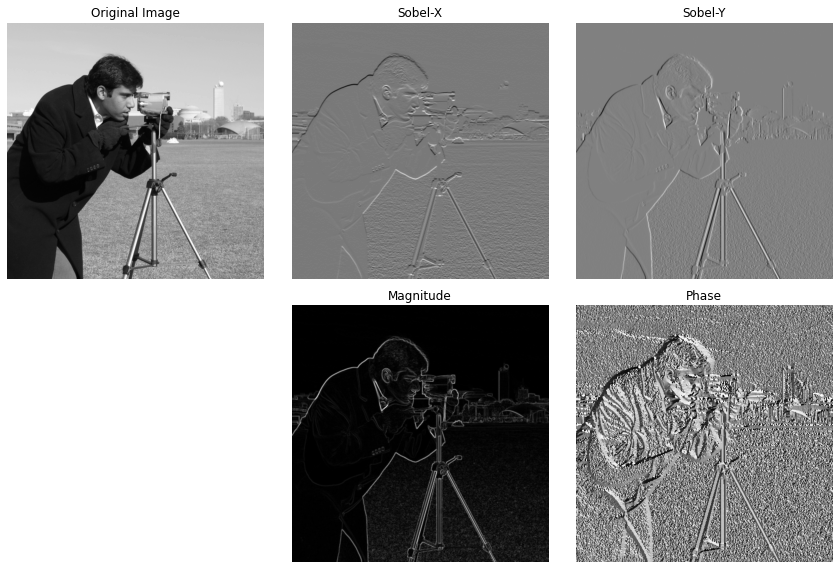

In [4]:
im = data.camera().astype("int32")
gx = ndi.sobel(im, axis=0)
gy = ndi.sobel(im, axis=1)
g_mag = np.abs(gx) + np.abs(gy)
g_phase = np.arctan2(gy, gx)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(im, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gx, cmap="gray")
plt.title("Sobel-X")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gy, cmap="gray")
plt.title("Sobel-Y")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(g_mag, cmap="gray")
plt.title("Magnitude")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(g_phase, cmap="gray")
plt.title("Phase")
plt.axis("off")

plt.tight_layout()
plt.show()

## 3. The second derivative convolution can detect blobs, which are bright on dark or dark on bright regions in an image. In the following link, blobs are detected using three algorithms: Laplacian of Gaussian, Difference of Gaussian, and Determinant of Hessian. The image used in this case is the Hubble Extreme Deep Field. Each bright dot in the image is a star or a galaxy. [https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_blob.html]
## Download Python source code: <`plot_blob.py`> from the link and run it. Answer the following questions:

### 3. a. How the three approaches work? Which approach is the most accurate and why?

Laplacian of Gaussian (LoG) approach processes through the image with Gaussian filters of succesively increasing standard deviation. For each Gaussian filtered image, the Laplacian (sum of horizontal and veritical second derivatives) is computed at each pixel. The resulting matrix with each given standard deviation $\sigma$ used in Gaussian filter is used in detecting blobs with a particular radius $r=\sqrt{2}\sigma$.

Difference of Gaussian (DoG) approach also applies Gaussian filters with succesively increasing standard deviation, and in the resulting sequence of blurred images, the difference is computed between every 2 consecutive blurred images, and then used as an estimate of Laplacian of Gaussian.

Determinant of Hessian (DoH) approach computes the Hessian matrix (second partial derivatives in the horizontal and vertical directions) at each pixel, and evaluates the determinants. The resulting DoH matrix is used for blob detection by finding local maxima and minima regions on the box-filtered image.

LoG appears to work the best overall. It is able to detect most of the blobs (stars or galaxies in the image), even the dim and small ones. DoG works almost equally as good, but miss some really small ones. DoH correctly detects the big blobs, but misses most of the small ones due to its nature. This is because LoG computes the solid brightness/intensity change of images with a range of Gaussian filter standard deviations, enabling its detection of blobs with sizes within the corresponding range given by $r = \sqrt2 \sigma$; DoG uses difference to estimate the Laplacian, resulting in some loss in accuracy; DoH misses small blobs since it uses a box filter on the resuling Hessian matrix.

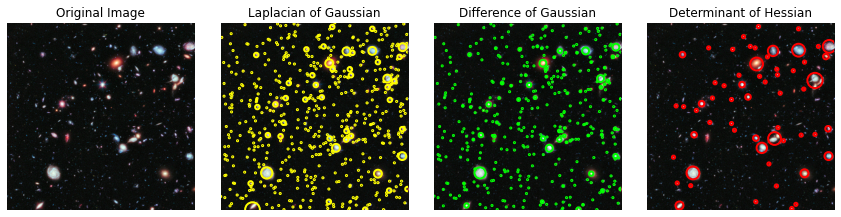

In [5]:
image = data.hubble_deep_field()[0:500, 0:500]
image_gray = rgb2gray(image)

blobs_log = blob_log(image_gray, max_sigma=30, num_sigma=10, threshold=0.1)
blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)

blobs_dog = blob_dog(image_gray, max_sigma=30, threshold=0.1)
blobs_dog[:, 2] = blobs_dog[:, 2] * np.sqrt(2)

blobs_doh = blob_doh(image_gray, max_sigma=30, threshold=0.01)

blobs_list = [[], blobs_log, blobs_dog, blobs_doh]
colors = ['', 'yellow', 'lime', 'red']
titles = ['Original Image', 'Laplacian of Gaussian', 
          'Difference of Gaussian', 'Determinant of Hessian']
sequence = zip(blobs_list, colors, titles)

fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharex=True, sharey=True)
ax = axes.ravel()

for idx, (blobs, color, title) in enumerate(sequence):
    ax[idx].set_title(title)
    ax[idx].imshow(image)
    for blob in blobs:
        y, x, r = blob
        c = plt.Circle((x, y), r, color=color, linewidth=2, fill=False)
        ax[idx].add_patch(c)
    ax[idx].set_axis_off()

plt.tight_layout()
plt.show()

### 3. b. Which approach is the fastest and why? Import a module `timeit` to measure execution time. Print the execution time for each approach. Check which approach uses the shortest time and answer why it is shortest?


In [6]:
# source: https://realpython.com/primer-on-python-decorators

import timeit
import functools

def time_exec(func, *, number=100):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start = timeit.default_timer()
        for _ in range(number):
            result = func(*args, **kwargs)
        end = timeit.default_timer()
        print(f"finished {func.__name__} for {number} loops, " +
              f"average execution time: {(end - start) / number:.6f} s.")
        return result
    return wrapper

In [7]:
image = data.hubble_deep_field()[0:500, 0:500]
image_gray = rgb2gray(image)

# laplacian of gaussian
@time_exec
def laplacian_of_gaussian(image_gray):
    blobs_log = blob_log(image_gray, max_sigma=30, num_sigma=10, threshold=0.1)
    blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)

# difference of gaussian
@time_exec
def difference_of_gaussian(image_gray):
    blobs_dog = blob_dog(image_gray, max_sigma=30, threshold=0.1)
    blobs_dog[:, 2] = blobs_dog[:, 2] * np.sqrt(2)

# determinant of hessian
@time_exec
def determinant_of_hessian(image_gray):
    blobs_doh = blob_doh(image_gray, max_sigma=30, threshold=0.01)

laplacian_of_gaussian(image_gray)
difference_of_gaussian(image_gray)
determinant_of_hessian(image_gray)

finished laplacian_of_gaussian for 100 loops, average execution time: 0.430144 s.
finished difference_of_gaussian for 100 loops, average execution time: 0.184487 s.
finished determinant_of_hessian for 100 loops, average execution time: 0.088453 s.


DoH approach uses the shortest time per execution because the compution only involves computing the determinant of Hessian matrix at each pixel once, while LoG and DoG approaches involve applying Gaussian filters with succesively increasing standard deviations and computing Laplacian/Difference on the resulting sequence of images, which means performing the computation on multiple images (number of images based on increment and range of Gaussian filters' standard deviations). Although the determinant of Hessian metrix at each pixel ($I_{xx}I_{yy} - I_{xy}^2$) could cost more time to compute than the Laplacian ($I_{xx}^2 + I_{yy}^2$) or the difference between two consecutive images in the sequence, HoG only needs to compute for image matrix, while LoG and DoG need to perform computations on a sequence of images. Therefore, DoH approach takes the shortest time to execute.

## 4. Compare Harris and Shi-Tomasi corner measures with the same image `data.camera()`. Use functions `corner_harris`, `corner_shi_tomasi`, `corner_subpix`, `corner_peaks`. Examples shown in the following link:
## [https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_corner.html]
## In the output image, mark the corners. Compare the outputs of the two corner-detection and explain the difference.

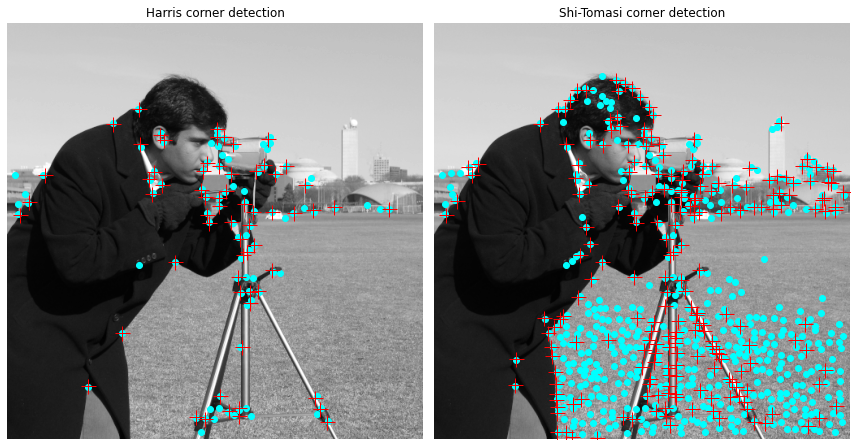

In [25]:
image = data.camera()

coords = corner_peaks(corner_harris(image), 
                      min_distance=5, threshold_rel=0.02)
coords_subpix = corner_subpix(image, coords, window_size=13)

coords2 = corner_peaks(corner_shi_tomasi(image), 
                       min_distance=5, threshold_rel=0.02)
coords_subpix2 = corner_subpix(image, coords2, window_size=13)

figure = plt.figure(figsize=(12, 12))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap=plt.cm.gray)
plt.plot(coords[:, 1], coords[:, 0],
         color='cyan', marker='o', linestyle='None',markersize=6)
plt.plot(coords_subpix[:, 1], coords_subpix[:, 0], '+r', markersize=15)
plt.title("Harris corner detection")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image, cmap=plt.cm.gray)
plt.plot(coords2[:, 1], coords2[:, 0],
         color='cyan', marker='o', linestyle='None',markersize=6)
plt.plot(coords_subpix2[:, 1], coords_subpix2[:, 0], '+r', markersize=15)
plt.title("Shi-Tomasi corner detection")
plt.axis("off")

plt.tight_layout()
plt.show()


More corners are marked by Shi-Tomasi corner detection as compared to those marked by Harris corner detection. Although Harris detector could have missed some corners in the result (such as some buildings' corners in the top right region), it appears that the Shi-Tomasi detector incorrectly marked many corners on the grass (some are excluded in subpixel positions, but still a few incorrect subpixel corners are marked, particularly in the lower right region and on the right edge of the person's leg). Overall, Harris detector seems to work better for this parameters set on this image.

The difference in the results is due to different criteria on classifying a region $\mathcal{R}$ as a corner. The Harris detector's criteria is when the gradient covariance matrix have both eigenvalues as large positive values, while the Shi-Tomasi detector only looks at the smaller eigenvalue among the two. Notice that the Harris detector uses a sensitivity factor $k$ that punishes detecting false corners, so that its result contains less incorrect corners in the grass region (although missing some real corners).

## 5. Feature detection and matching.

### 5. a. Download the following image < `book.jpg` > from the folder Lab4.

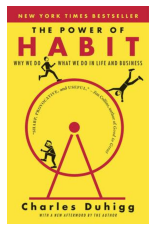

In [26]:
im = cv2.imread("book.jpg", cv2.IMREAD_COLOR_RGB)

plt.imshow(im)
plt.axis("off")
plt.show()

### 5. b. Use `skimage.transform.AffineTransform` to conduct transformation of translation, rotation, scale, and shear. Save the transformed image as < `transformed.jpg` >.

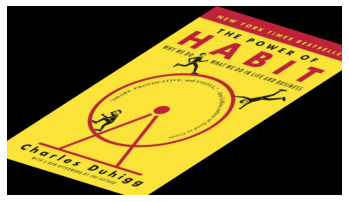

In [27]:
tform = AffineTransform(scale=(1.3, 1.1), rotation=0.3, shear=0.7, 
                        translation=(500, 0))
im_transformed = warp(im, tform.inverse, output_shape=(450, 800))
im_transformed = (im_transformed * 255).astype(np.uint8)
cv2.imwrite("transformed.jpg", cv2.cvtColor(im_transformed, cv2.COLOR_RGB2BGR))
plt.imshow(im_transformed)
plt.axis("off")
plt.show()

### 5. c. Use three methods: CENSURE, ORB, and SIFT to extract descriptors in the two images and mark the descriptors in the two images.

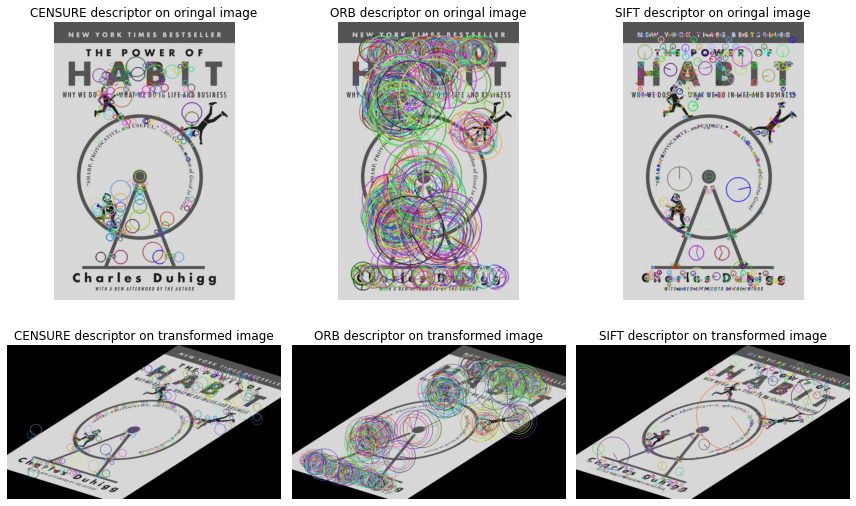

In [28]:
im = cv2.imread("book.jpg")
im_transformed = cv2.imread("transformed.jpg")
im_g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
im_t_g = cv2.cvtColor(im_transformed, cv2.COLOR_BGR2GRAY)

methods = ["CENSURE", "ORB", "SIFT"]
results_1 = []
results_2 = []
labeled_1 = []
labeled_2 = []
detectors = [
    cv2.xfeatures2d.StarDetector_create(), 
    cv2.ORB_create(), 
    cv2.SIFT_create()
]

figure = plt.figure(figsize=(12, 8))

for i in range(3):
    try:
        results_1.append(detectors[i].detectAndCompute(im_g, None))
        results_2.append(detectors[i].detectAndCompute(im_t_g, None))
    except:
        results_1.append((detectors[i].detect(im_g, None), None))
        results_2.append((detectors[i].detect(im_t_g, None), None))
    labeled_1.append(
        cv2.drawKeypoints(im_g, results_1[-1][0], im.copy(), 
                          flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS))
    labeled_2.append(
        cv2.drawKeypoints(im_t_g, results_2[-1][0], im_transformed.copy(), 
                          flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS))

    plt.subplot(2, 3, i + 1)
    plt.imshow(labeled_1[-1])
    plt.axis("off")
    plt.title(f"{methods[i]} descriptor on oringal image")

    plt.subplot(2, 3, i + 4)
    plt.imshow(labeled_2[-1])
    plt.axis("off")
    plt.title(f"{methods[i]} descriptor on transformed image")

plt.tight_layout()
plt.show()

### 5. d. For descriptors detected by ORB and SIFT, use a matching method: e.g. {`skimage.feature.match_descriptors`} or {`cv2.BFMatcher.knnMatch`} or {`cv2.FlannBasedMatcher.knnMatch`} to match the descriptors in the two images; show the matching in the two images.

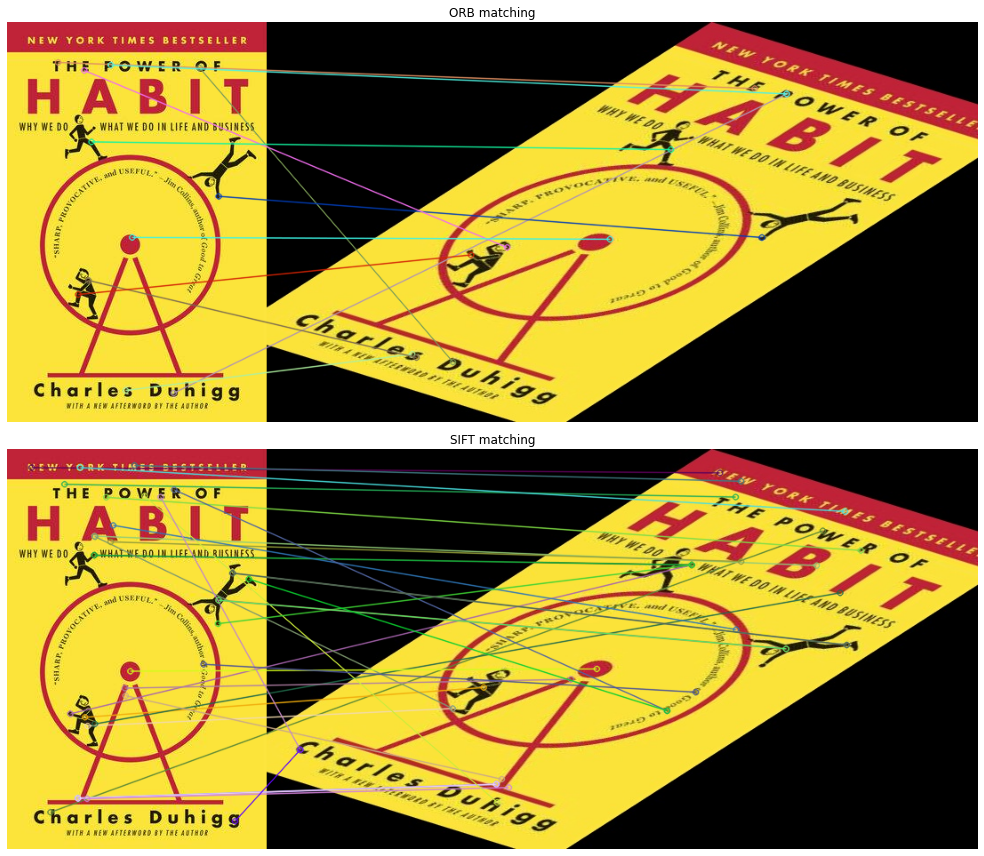

In [29]:
n_matches = 10

bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING)
matches_orb = bf_orb.knnMatch(results_1[1][1], results_2[1][1], k=2)
matches_orb_good = []
for m, n in matches_orb:
    if m.distance < 0.75 * n.distance:
        matches_orb_good.append([m])
labeled_orb = cv2.drawMatchesKnn(im, results_1[1][0],
                                 im_transformed, results_2[1][0],
                                 matches_orb_good, None, flags=2)

bf_sift = cv2.BFMatcher()
matches_sift = bf_sift.knnMatch(results_1[2][1], results_2[2][1], k=2)
matches_sift_good = []
for m, n in matches_sift:
    if m.distance < 0.75 * n.distance:
        matches_sift_good.append([m])
labeled_sift = cv2.drawMatchesKnn(im, results_1[2][0],
                                  im_transformed, results_2[2][0],
                                  matches_sift_good, None, flags=2)

figure = plt.figure(figsize=(14, 12))
plt.subplot(2, 1, 1)
plt.imshow(cv2.cvtColor(labeled_orb, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("ORB matching")

plt.subplot(2, 1, 2)
plt.imshow(cv2.cvtColor(labeled_sift, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("SIFT matching")

plt.tight_layout()
plt.show()

### 5. e. Compare the performance of ORB and SIFT, which one works the best? Why? (compare at least two performance metrics, e.g. The Putative Match Ratio = \# of putative matches / \# of features and the execution time)

In [13]:
@time_exec
def match_descriptors_orb():
    bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING)
    bf_orb.knnMatch(results_1[1][1], results_2[1][1], k=2)

@time_exec
def match_descriptors_sift():
    bf_sift = cv2.BFMatcher()
    bf_sift.knnMatch(results_1[2][1], results_2[2][1], k=2)

putative_match_ratio_orb = len(matches_orb_good) / len(results_1[1][0])
putative_match_ratio_sift = len(matches_sift_good) / len(results_1[2][0])

print(f"Putative Match Ratio for ORB: {putative_match_ratio_orb}")
match_descriptors_orb()

print(f"Putative Match Ratio for SIFT: {putative_match_ratio_sift}")
match_descriptors_sift()

Putative Match Ratio for ORB: 0.022587268993839837
finished match_descriptors_orb for 100 loops, average execution time: 0.000389 s.
Putative Match Ratio for SIFT: 0.051515151515151514
finished match_descriptors_sift for 100 loops, average execution time: 0.000886 s.


In terms of Putative Match Ratio, SIFT is better than ORB, meaning SIFT finds relatively more matches among its detected keypoints than ORB does. However, SIFT takes relatively longer time to execute. In this case, the execution times for both approaches are fast (less than a fraction of a second), so the execution time can be considered as a less important factor. Therefore, it is concluded that SIFT works better.

### 5. f. Download two images <`IMG_1.jpg`> and <`IMG_2.jpg`> from the folder for feature detection and matching. Use the best detection method you identify in step (e).

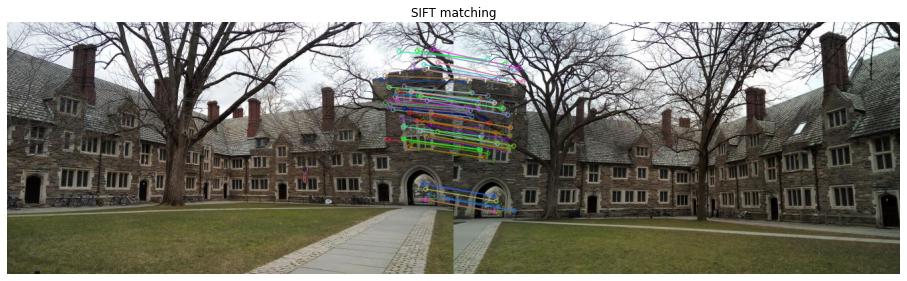

In [30]:
im_1 = cv2.imread("IMG_1.jpg", cv2.IMREAD_COLOR_RGB)
im_2 = cv2.imread("IMG_2.jpg", cv2.IMREAD_COLOR_RGB)
im_1_g = cv2.cvtColor(im_1, cv2.COLOR_RGB2GRAY)
im_2_g = cv2.cvtColor(im_2, cv2.COLOR_RGB2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(im_1_g, None)
kp2, des2 = sift.detectAndCompute(im_2_g, None)

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    if m.distance < 0.5 * n.distance:
        good.append([m])

labeled_sift = cv2.drawMatchesKnn(im_1, kp1,
                                  im_2, kp2,
                                  good, None, flags=2)

plt.figure(figsize=(16, 6))
plt.imshow(labeled_sift)
plt.axis("off")
plt.title("SIFT matching")

# # matches IMG_2 onto IMG_1
# matches = np.asarray(good)
# if len(matches[:, 0]) >= 4:
#     src = np.float32(
#         [kp2[m.trainIdx].pt for m in matches[:, 0]]).reshape(-1, 1, 2)
#     dst = np.float32(
#         [kp1[m.queryIdx].pt for m in matches[:, 0]]).reshape(-1, 1, 2)
#     H, _ = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
# else:
#     raise AssertionError("Can't find enough keypoints.")

# dst = cv2.warpPerspective(im_2, H,
#                           (im_1.shape[1] + im_2.shape[1] * 2, im_2.shape[0]))
# dst[0:im_1.shape[0], 0:im_1.shape[1]] = im_1
# cv2.imwrite("stitched.jpg", cv2.cvtColor(dst, cv2.COLOR_RGB2BGR))

# # matches IMG_1 onto IMG_2 instead, by first extending IMG_2 to the left
# im_2_ext = np.concatenate(
#     (np.zeros_like(im_1), np.zeros_like(im_1), im_2), axis=1)
# im_2_ext_g = cv2.cvtColor(im_2_ext, cv2.COLOR_RGB2GRAY)
# kp2ext, des2ext = sift.detectAndCompute(im_2_ext_g, None)
# matches_with_ext = bf.knnMatch(des1, des2ext, k=2)
# good_ext = []
# for m, n in matches_with_ext:
#     if m.distance < 0.5 * n.distance:
#         good_ext.append([m])
# labeled_sift_ext = cv2.drawMatchesKnn(im_1_g, kp1, im_2_ext_g, kp2ext, 
#                                       good_ext, None, flags=2)
# matches_ext = np.asarray(good_ext)
# src_ext = np.float32(
#     [kp1[m.queryIdx].pt for m in matches_ext[:, 0]]).reshape(-1, 1, 2)
# dst_ext = np.float32(
#     [kp2ext[m.trainIdx].pt for m in matches_ext[:, 0]]).reshape(-1, 1, 2)
# H_ext, _ = cv2.findHomography(src_ext, dst_ext, cv2.RANSAC, 5.0)
# dst_ext = cv2.warpPerspective(im_1, H_ext,
#                               (im_2_ext.shape[1], im_2_ext.shape[0]))
# dst_ext[:, -im_2.shape[1]:] = im_2
# cv2.imwrite("stitched_2.jpg", cv2.cvtColor(dst_ext, cv2.COLOR_RGB2BGR))


# fig, axs = plt.subplots(3, 3, figsize=(14, 10))
# for ax in axs.ravel():
#     ax.axis("off")

# ax_1 = fig.add_subplot(axs[0, 0].get_gridspec()[0, :])
# ax_1.imshow(labeled_sift)
# ax_1.set_title("SIFT matching")
# ax_1.axis("off")

# ax_2 = fig.add_subplot(axs[1, 0].get_gridspec()[1, :])
# ax_2.imshow(dst)
# ax_2.set_title("stitched image - IMG_2 put onto IMG_1")
# ax_2.axis("off")

# ax_3 = fig.add_subplot(axs[2, 0].get_gridspec()[2, :])
# ax_3.imshow(dst_ext)
# ax_3.set_title("stitched image - IMG_1 put onto IMG_2")
# ax_3.axis("off")

# plt.tight_layout()
plt.show()
